# MVP — Machine Learning & Analytics

**Nome:** _José Iran de Melo Júnior_  
**Matrícula:** _4052026001057_   
**Data:** _01/07/2026_  
**Dataset:** _Default of Credit Card Clients | https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients_  
**Arquivo para execução:** _https://raw.githubusercontent.com/XAKCN/Machine-Learning_Puc-Rio/main/default%20of%20credit%20card%20clients.xls_  
**Tipo de problema:** _Classificação_    

## Introdução

Este notebook apresenta um **MVP (Minimum Viable Product)** de Machine Learning aplicado à previsão de inadimplência de clientes de cartão de crédito. Trata-se de um problema de **classificação binária supervisionada**, cujo objetivo é estimar se um cliente entrará em default no mês seguinte.

O notebook foi construído como um **relatório técnico executável**, combinando código Python, explicações em português, tabelas, visualizações, métricas e conclusão crítica. O estudo tem finalidade exclusivamente acadêmica e não constitui um sistema de decisão de crédito para produção.


## 1. Definição do Problema

### Problema Selecionado

O problema selecionado é a **previsão de inadimplência de clientes de cartão de crédito** (*credit card default prediction*). Dado o histórico financeiro e comportamental de um cliente, deseja-se estimar a probabilidade de que esse cliente venha a inadimplir no próximo mês.

### Objetivo do Modelo

Construir um modelo preditivo capaz de **estimar a probabilidade de default** de um cliente com base em variáveis demográficas, financeiras e de histórico de pagamento.

### Variável-Alvo

A variável-alvo foi renomeada para **`inadimplente_proximo_mes`** e assume os seguintes valores:

- **`0`** = cliente adimplente (não inadimplente no mês seguinte)
- **`1`** = cliente inadimplente (default no mês seguinte)

### Tipo de Tarefa

Esta é uma tarefa de **classificação supervisionada binária**, pois:

1. Existe um conjunto de dados rotulado com a variável-alvo conhecida;
2. A variável-alvo possui apenas duas classes possíveis (0 ou 1);
3. O objetivo é aprender uma função de mapeamento $f(X) \rightarrow y$ a partir dos dados históricos.

### Por Que Machine Learning é Apropriado?

Machine Learning é adequado para este problema porque:

- Existe um **volume significativo de dados históricos** com a variável-alvo conhecida;
- As relações entre as variáveis de entrada e a inadimplência são **não-lineares e multivariadas**, dificilmente capturadas por regras fixas;
- Os padrões de comportamento de pagamento contêm **sinais preditivos** sobre o risco futuro do cliente.

### Hipóteses e Suposições Principais

1. O **histórico de pagamento recente** contém informação preditiva sobre o comportamento futuro do cliente;
2. **Padrões de fatura e pagamento** (razões entre valores devidos e pagos) estão correlacionados com a propensão ao default;
3. **Variáveis demográficas** (idade, escolaridade, estado civil) agregam poder discriminatório quando combinadas com variáveis comportamentais;
4. Os dados históricos são **representativos** da população-alvo para fins acadêmicos.

### Restrições e Limitações

- Este é um **MVP acadêmico**, não um sistema de credit scoring para produção;
- O dataset refere-se a clientes de **Taiwan** e não pode ser diretamente generalizado para o mercado brasileiro sem validação adicional;
- Não são disponibilizadas variáveis como renda, ocupação, histórico bancário completo ou indicadores macroeconômicos;
- O modelo não considera aspectos temporais explícitos, pois o problema não é tratado como série temporal.


In [31]:
import time
NOTEBOOK_START = time.perf_counter()

%pip install xlrd python-dotenv -q

import sys
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracao visual global
sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("notebook", font_scale=1.0)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"
plt.rcParams["text.color"] = "#333333"

import sklearn
from IPython.display import Markdown, display
from dotenv import load_dotenv

load_dotenv(Path.cwd() / ".env")


def _parse_env(name: str, default: str, typ=int) -> int | float:
    """Parse an environment variable, raising ValueError with context on failure."""
    raw = os.getenv(name, default)
    try:
        return typ(raw)
    except (ValueError, TypeError) as exc:
        raise ValueError(
            f"Environment variable {name!r} has invalid value {raw!r}: {exc}"
        ) from exc


RANDOM_STATE = _parse_env("RANDOM_STATE", "42", int)
CV_SPLITS = _parse_env("CV_SPLITS", "3", int)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


Note: you may need to restart the kernel to use updated packages.
Python: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.9.0


## 2. Apresentação dos Dados

### Dataset

| Atributo | Descrição |
|----------|-----------|
| **Nome** | Default of Credit Card Clients |
| **Fonte** | UCI Machine Learning Repository |
| **ID** | 350 |
| **URL** | https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients |
| **DOI** | https://doi.org/10.24432/C55S3H |
| **Repositorio GitHub do MVP** | https://github.com/XAKCN/Machine-Learning_Puc-Rio |
| **Arquivo usado no notebook** | https://raw.githubusercontent.com/XAKCN/Machine-Learning_Puc-Rio/main/default%20of%20credit%20card%20clients.xls |
| **Registros** | 30.000 |
| **Atributos explicativos originais** | 23 |
| **Variável-alvo** | `inadimplente_proximo_mes` (0 = adimplente, 1 = inadimplente) |

**Referência do dataset:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

### Grupos de Variáveis

| Grupo | Variáveis | Descrição |
|-------|-----------|-----------|
| **Limite de crédito** | `limite_credito` | Valor do limite de crédito concedido (NT dollar) |
| **Demográficas** | `sexo`, `escolaridade`, `estado_civil`, `idade` | Gênero, escolaridade, estado civil e idade |
| **Histórico de pagamento** | `status_pagamento_1` a `status_pagamento_6` | Status de pagamento dos últimos 6 meses |
| **Valores de fatura** | `valor_fatura_1` a `valor_fatura_6` | Valor da fatura de cartão de crédito dos últimos 6 meses |
| **Valores pagos** | `valor_pagamento_1` a `valor_pagamento_6` | Valor do pagamento efetuado nos últimos 6 meses |
| **Alvo** | `inadimplente_proximo_mes` | Inadimplência no mês seguinte (0/1) |

### Limitações Conhecidas

1. **Contexto geográfico:** os dados referem-se a clientes de Taiwan, com características socioeconômicas e regulatórias distintas do Brasil;
2. **Amostra histórica:** os registros financeiros se referem a 2005 e podem não representar o comportamento atual de crédito;
3. **Variáveis limitadas:** não há informações de renda, ocupação, patrimônio, histórico bancário completo ou variáveis macroeconômicas;
4. **Generalização restrita:** o modelo não foi validado com dados brasileiros e não deve ser usado para decisões reais de crédito;
5. **Escopo acadêmico:** este MVP demonstra um processo de Machine Learning, mas não atende aos requisitos regulatórios, de governança, monitoramento e validação de um score de produção.


In [32]:
# Carregamento direto do arquivo XLS hospedado no repositorio GitHub do MVP
DATASET_URL = os.getenv(
    "DATASET_URL",
    "https://raw.githubusercontent.com/XAKCN/Machine-Learning_Puc-Rio/main/default%20of%20credit%20card%20clients.xls"
)

df = pd.read_excel(DATASET_URL, header=1)

rename_map = {
    "LIMIT_BAL": "limite_credito",
    "SEX": "sexo",
    "EDUCATION": "escolaridade",
    "MARRIAGE": "estado_civil",
    "AGE": "idade",
    "PAY_0": "status_pagamento_1",
    "PAY_2": "status_pagamento_2",
    "PAY_3": "status_pagamento_3",
    "PAY_4": "status_pagamento_4",
    "PAY_5": "status_pagamento_5",
    "PAY_6": "status_pagamento_6",
    "BILL_AMT1": "valor_fatura_1",
    "BILL_AMT2": "valor_fatura_2",
    "BILL_AMT3": "valor_fatura_3",
    "BILL_AMT4": "valor_fatura_4",
    "BILL_AMT5": "valor_fatura_5",
    "BILL_AMT6": "valor_fatura_6",
    "PAY_AMT1": "valor_pagamento_1",
    "PAY_AMT2": "valor_pagamento_2",
    "PAY_AMT3": "valor_pagamento_3",
    "PAY_AMT4": "valor_pagamento_4",
    "PAY_AMT5": "valor_pagamento_5",
    "PAY_AMT6": "valor_pagamento_6",
    "default payment next month": "inadimplente_proximo_mes",
}

missing_expected = set(rename_map.keys()) - set(df.columns)
if missing_expected:
    raise ValueError(
        f"Dataset is missing expected columns: {sorted(missing_expected)}. "
        f"Available columns: {sorted(df.columns)}"
    )

df = df.rename(columns=rename_map)

if "ID" in df.columns:
    df = df.drop(columns="ID")

if df.empty:
    raise ValueError("Dataset is empty after loading.")

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")


Dataset carregado: 30000 linhas x 24 colunas
Colunas: ['limite_credito', 'sexo', 'escolaridade', 'estado_civil', 'idade', 'status_pagamento_1', 'status_pagamento_2', 'status_pagamento_3', 'status_pagamento_4', 'status_pagamento_5', 'status_pagamento_6', 'valor_fatura_1', 'valor_fatura_2', 'valor_fatura_3', 'valor_fatura_4', 'valor_fatura_5', 'valor_fatura_6', 'valor_pagamento_1', 'valor_pagamento_2', 'valor_pagamento_3', 'valor_pagamento_4', 'valor_pagamento_5', 'valor_pagamento_6', 'inadimplente_proximo_mes']


## 3. Análise Exploratória Inicial

A Análise Exploratória de Dados (EDA) permite compreender a estrutura, distribuição e qualidade das variáveis antes da modelagem. Todas as visualizações são construídas com **matplotlib** e seaborn.


In [33]:
# Primeiras linhas
display(df.head())

# Informações dos tipos de dados
df.info()

# Estatísticas descritivas
display(df.describe().T.round(2))


,limite_credito,sexo,escolaridade,estado_civil,idade,status_pagamento_1,status_pagamento_2,status_pagamento_3,status_pagamento_4,status_pagamento_5,status_pagamento_6,valor_fatura_1,valor_fatura_2,valor_fatura_3,valor_fatura_4,valor_fatura_5,valor_fatura_6,valor_pagamento_1,valor_pagamento_2,valor_pagamento_3,valor_pagamento_4,valor_pagamento_5,valor_pagamento_6,inadimplente_proximo_mes
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   limite_credito            30000 non-null  int64
 1   sexo                      30000 non-null  int64
 2   escolaridade              30000 non-null  int64
 3   estado_civil              30000 non-null  int64
 4   idade                     30000 non-null  int64
 5   status_pagamento_1        30000 non-null  int64
 6   status_pagamento_2        30000 non-null  int64
 7   status_pagamento_3        30000 non-null  int64
 8   status_pagamento_4        30000 non-null  int64
 9   status_pagamento_5        30000 non-null  int64
 10  status_pagamento_6        30000 non-null  int64
 11  valor_fatura_1            30000 non-null  int64
 12  valor_fatura_2            30000 non-null  int64
 13  valor_fatura_3            30000 non-null  int64
 14  valor_fatura_4            30000 non-null  int64
 

,count,mean,std,min,25%,50%,75%,max
limite_credito,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
sexo,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
escolaridade,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
estado_civil,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
idade,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
status_pagamento_1,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
status_pagamento_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
status_pagamento_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
status_pagamento_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
status_pagamento_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0


In [34]:
# Resumo de valores ausentes
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_summary)


,missing_count,missing_percent
limite_credito,0,0.0
sexo,0,0.0
escolaridade,0,0.0
estado_civil,0,0.0
idade,0,0.0
status_pagamento_1,0,0.0
status_pagamento_2,0,0.0
status_pagamento_3,0,0.0
status_pagamento_4,0,0.0
status_pagamento_5,0,0.0


,count,percent
inadimplente_proximo_mes,,
0,23364,77.88
1,6636,22.12


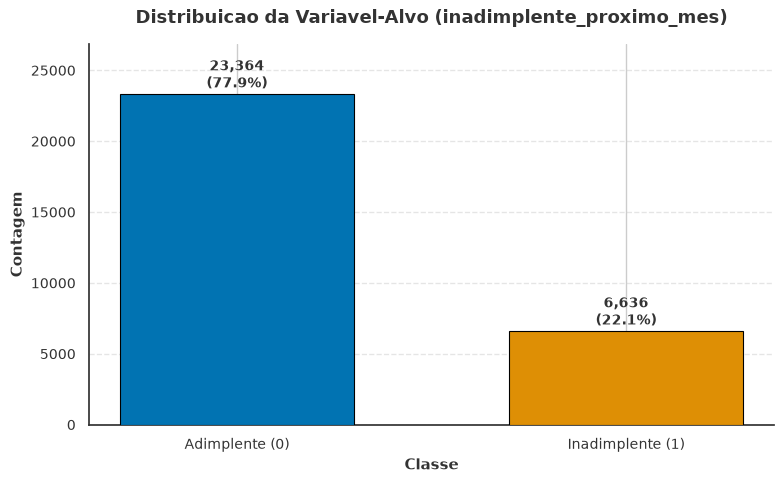

In [35]:
# Distribuicao da variavel-alvo
target_counts = df["inadimplente_proximo_mes"].value_counts().sort_index()
target_percent = df["inadimplente_proximo_mes"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

display(target_distribution)

# Plot da distribuicao do target
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#0173B2", "#DE8F05"]  # paleta colorblind-friendly
bars = ax.bar(
    target_distribution.index.astype(str),
    target_distribution["count"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6,
    zorder=3
)
ax.set_xlabel("Classe", fontweight="bold")
ax.set_ylabel("Contagem", fontweight="bold")
ax.set_title("Distribuicao da Variavel-Alvo (inadimplente_proximo_mes)", fontweight="bold", pad=15)
ax.set_xticks(target_distribution.index.astype(str))
ax.set_xticklabels(["Adimplente (0)", "Inadimplente (1)"])
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 100,
        f"{int(height):,}\n({height/len(df)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10
    )

sns.despine(ax=ax)
ax.set_ylim(0, max(target_distribution["count"]) * 1.15)
plt.tight_layout()
plt.show()


In [36]:
# Análise de variáveis categóricas
categorical_cols = ["sexo", "escolaridade", "estado_civil"]

for col in categorical_cols:
    print(f"\nVariável: {col}")
    print(df[col].value_counts().sort_index())



Variável: sexo
sexo
1    11888
2    18112
Name: count, dtype: int64

Variável: escolaridade
escolaridade
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Variável: estado_civil
estado_civil
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [37]:
# Resumo das variáveis de status de pagamento
payment_status_cols = ["status_pagamento_1", "status_pagamento_2", "status_pagamento_3", "status_pagamento_4", "status_pagamento_5", "status_pagamento_6"]
display(df[payment_status_cols].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
status_pagamento_1,30000.0,-0.02,1.12,-2.0,-1.0,0.0,0.0,8.0
status_pagamento_2,30000.0,-0.13,1.20,-2.0,-1.0,0.0,0.0,8.0
status_pagamento_3,30000.0,-0.17,1.20,-2.0,-1.0,0.0,0.0,8.0
status_pagamento_4,30000.0,-0.22,1.17,-2.0,-1.0,0.0,0.0,8.0
status_pagamento_5,30000.0,-0.27,1.13,-2.0,-1.0,0.0,0.0,8.0
status_pagamento_6,30000.0,-0.29,1.15,-2.0,-1.0,0.0,0.0,8.0


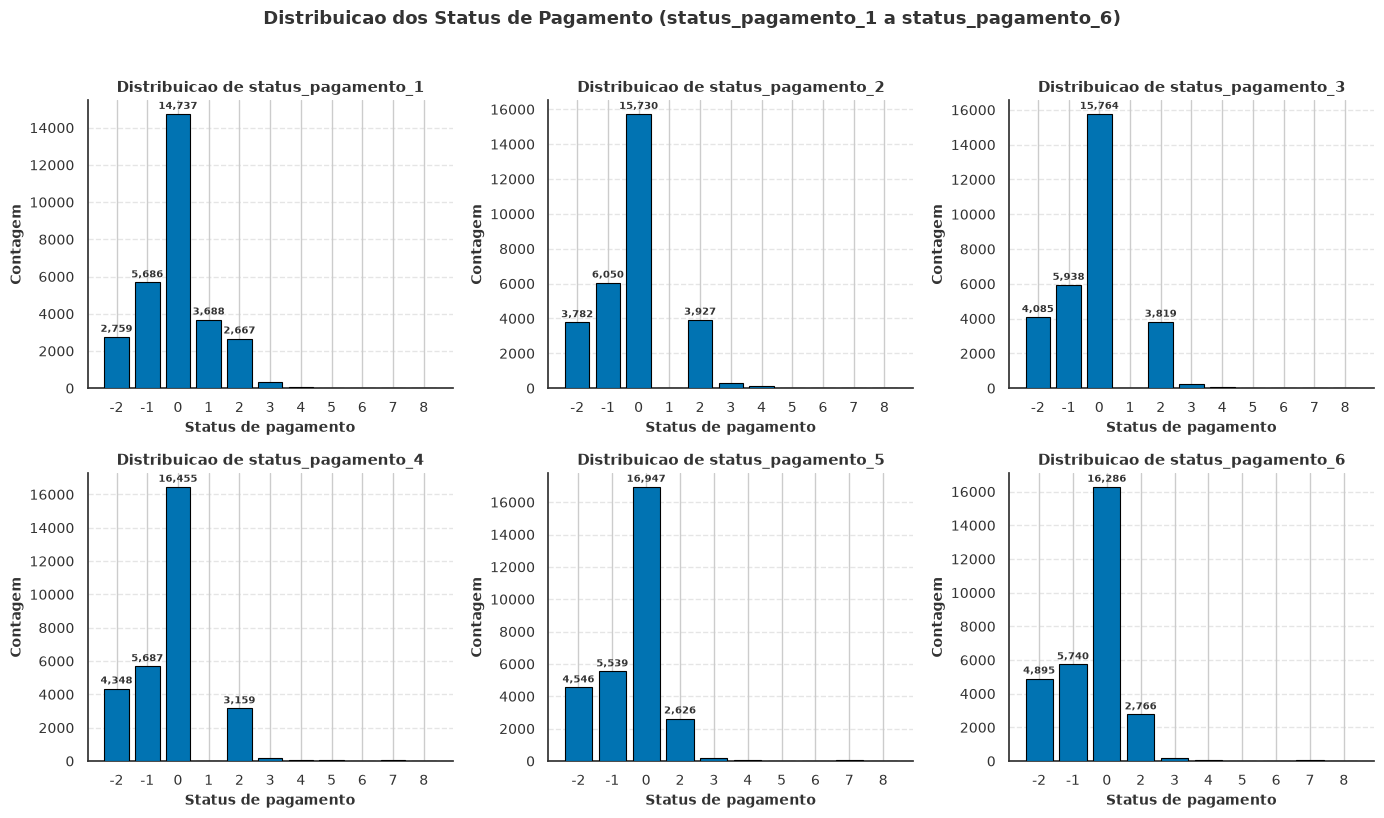

In [38]:
# Distribuicao das variaveis de status de pagamento
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(payment_status_cols):
    counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(
        counts.index.astype(str),
        counts.values,
        color="#0173B2",
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )
    axes[i].set_title(f"Distribuicao de {col}", fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Status de pagamento", fontweight="bold", fontsize=10)
    axes[i].set_ylabel("Contagem", fontweight="bold", fontsize=10)
    axes[i].yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    sns.despine(ax=axes[i])

    # Anotacoes de valor para barras principais
    for bar in bars:
        height = bar.get_height()
        if height > 500:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2.0,
                height + max(counts.values) * 0.01,
                f"{int(height):,}",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold"
            )

plt.suptitle("Distribuicao dos Status de Pagamento (status_pagamento_1 a status_pagamento_6)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


,correlation
inadimplente_proximo_mes,1.0000
status_pagamento_1,0.3248
status_pagamento_2,0.2636
status_pagamento_3,0.2353
status_pagamento_4,0.2166
status_pagamento_5,0.2041
status_pagamento_6,0.1869
escolaridade,0.0280
idade,0.0139
valor_fatura_6,-0.0054


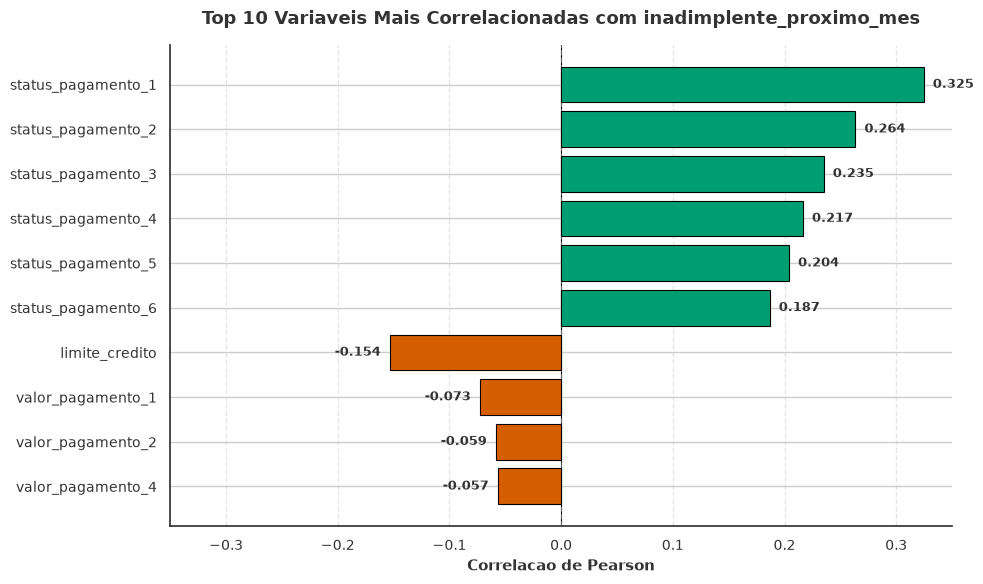

In [39]:
# Correlacao das variaveis numericas com o target
correlation_with_target = (
    df.corr(numeric_only=True)["inadimplente_proximo_mes"]
    .sort_values(ascending=False)
)

display(correlation_with_target.to_frame("correlation").head(15).round(4))

# Plot das 10 correlacoes mais fortes (positivas e negativas)
top_corr = correlation_with_target.drop("inadimplente_proximo_mes")
top_corr = top_corr.reindex(top_corr.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#029E73" if v > 0 else "#D55E00" for v in top_corr.values]
bars = ax.barh(
    range(len(top_corr)),
    top_corr.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Correlacao de Pearson", fontweight="bold")
ax.set_title("Top 10 Variaveis Mais Correlacionadas com inadimplente_proximo_mes", fontweight="bold", pad=15)
ax.axvline(0, color="black", linewidth=0.8, zorder=0)
ax.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)

# Adiciona rotulos de valor
for i, v in enumerate(top_corr.values):
    offset = 0.008 if v > 0 else -0.008
    ha_align = "left" if v > 0 else "right"
    ax.text(v + offset, i, f"{v:.3f}",
            va="center", ha=ha_align, fontsize=9, fontweight="bold")

sns.despine(ax=ax)
ax.set_xlim(-0.35, 0.35)
plt.tight_layout()
plt.show()


## 4. Preparação dos Dados

Nesta etapa, os dados são preparados para a modelagem. As transformações aplicadas incluem correção de categorias inconsistentes, mapeamento de variáveis categóricas para rótulos descritivos, criação de *features* financeiras derivadas e construção de um pipeline de pré-processamento reproduzível.

### Criação de Features Derivadas

Duas razões financeiras simples são criadas a partir dos dados existentes:

- **`razao_fatura_limite`**: razão entre o valor da fatura mais recente e o limite de crédito;
- **`razao_pagamento_fatura`**: razão entre o pagamento mais recente e a fatura do mês anterior.

Essas features são calculadas **linha a linha**, sem usar o target ou estatísticas globais. Portanto, não introduzem *data leakage*.

### Justificativa para o Tratamento de `status_pagamento_1` a `status_pagamento_6`

Embora estejam armazenadas como números inteiros, as variáveis `status_pagamento_1` a `status_pagamento_6` representam **estados discretos de pagamento**, e não grandezas quantitativas contínuas. Elas incluem códigos especiais como `-2`, `-1` e `0`, além dos códigos associados a meses de atraso. Tratar esses valores como numéricos e aplicar `StandardScaler` imporia uma relação linear e distâncias artificiais entre estados cujo significado é categórico. Por esse motivo, essas variáveis são incluídas no grupo categórico e transformadas com `OneHotEncoder(handle_unknown="ignore")`. Essa decisão preserva o significado dos códigos e permite que os modelos aprendam efeitos distintos para cada status de pagamento.


In [40]:
# Cópia para preparação
df_model = df.copy()

# Limpeza de categorias inconsistentes
df_model["escolaridade"] = df_model["escolaridade"].replace({
    0: 4,
    5: 4,
    6: 4
})

df_model["estado_civil"] = df_model["estado_civil"].replace({
    0: 3
})

# Mapeamento de variáveis categóricas para rótulos descritivos
def _safe_map(series: pd.Series, mapping: dict, col_name: str) -> pd.Series:
    """Map values, raising on unmapped keys instead of producing silent NaNs."""
    unmapped = set(series.unique()) - set(mapping.keys())
    if unmapped:
        raise ValueError(
            f"Column {col_name!r} contains unmapped values: {sorted(unmapped)}. "
            f"Expected only: {sorted(mapping.keys())}"
        )
    return series.map(mapping)


df_model["sexo"] = _safe_map(df_model["sexo"], {
    1: "male",
    2: "female"
}, "sexo")

df_model["escolaridade"] = _safe_map(df_model["escolaridade"], {
    1: "graduate_school",
    2: "university",
    3: "high_school",
    4: "others"
}, "escolaridade")

df_model["estado_civil"] = _safe_map(df_model["estado_civil"], {
    1: "married",
    2: "single",
    3: "others"
}, "estado_civil")

# Criação de features financeiras derivadas
df_model["razao_fatura_limite"] = np.where(
    df_model["limite_credito"] != 0,
    df_model["valor_fatura_1"] / df_model["limite_credito"],
    0
)

df_model["razao_pagamento_fatura"] = np.where(
    df_model["valor_fatura_2"] != 0,
    df_model["valor_pagamento_1"] / df_model["valor_fatura_2"],
    0
)

_ratio_cols = ["razao_fatura_limite", "razao_pagamento_fatura"]
_inf_count = np.isinf(df_model[_ratio_cols]).sum().sum()
_nan_count = df_model[_ratio_cols].isna().sum().sum()
if _inf_count or _nan_count:
    import warnings
    warnings.warn(
        f"Replaced {_inf_count} inf and {_nan_count} NaN values in ratio columns with 0.",
        stacklevel=2,
    )
df_model[_ratio_cols] = (
    df_model[_ratio_cols]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

# Separação entre features (X) e target (y)
target = "inadimplente_proximo_mes"

if target not in df_model.columns:
    raise KeyError(
        f"Target column {target!r} not found in DataFrame. "
        f"Available columns: {sorted(df_model.columns)}"
    )
X = df_model.drop(columns=[target, "ID"], errors="ignore")
y = df_model[target].astype(int)

print(f"Features: {X.shape[1]} variáveis")
print(f"Amostras: {X.shape[0]}")
print(f"Target: {y.value_counts().to_dict()}")


Features: 25 variáveis
Amostras: 30000
Target: {0: 23364, 1: 6636}


In [41]:
# Definição dos grupos de features
payment_status_cols = ["status_pagamento_1", "status_pagamento_2", "status_pagamento_3", "status_pagamento_4", "status_pagamento_5", "status_pagamento_6"]

categorical_features = [
    "sexo",
    "escolaridade",
    "estado_civil",
    *payment_status_cols
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print(f"Variáveis numéricas: {len(numeric_features)}")
print(f"Variáveis categóricas: {len(categorical_features)}")
print(f"Categóricas: {categorical_features}")

# Construção do pipeline de pré-processamento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Pipeline de pré-processamento construído com sucesso.")


Variáveis numéricas: 16
Variáveis categóricas: 9
Categóricas: ['sexo', 'escolaridade', 'estado_civil', 'status_pagamento_1', 'status_pagamento_2', 'status_pagamento_3', 'status_pagamento_4', 'status_pagamento_5', 'status_pagamento_6']
Pipeline de pré-processamento construído com sucesso.


### Por Que Usar Pipelines?

O uso de **`Pipeline`** e **`ColumnTransformer`** do scikit-learn é uma prática fundamental:

1. **Reprodutibilidade:** as transformações e o modelo ficam encapsulados no mesmo fluxo;
2. **Organização:** variáveis numéricas e categóricas recebem tratamentos explícitos;
3. **Prevenção de data leakage:** imputadores, scaler e encoder são ajustados apenas nos dados de treino de cada fold;
4. **Consistência:** o mesmo processamento aprendido no treino é aplicado ao teste sem reajuste;
5. **Tratamento semântico:** variáveis nominais e códigos de status de pagamento usam `OneHotEncoder`, enquanto variáveis quantitativas usam `StandardScaler`.


## 5. Divisão dos Dados

A divisão entre treino e teste é realizada de forma **estratificada**, preservando a proporção das classes em ambos os conjuntos. A validação cruzada é aplicada **exclusivamente nos dados de treino**.


In [42]:
from sklearn.model_selection import train_test_split, StratifiedKFold

TEST_SIZE = _parse_env("TEST_SIZE", "0.20", float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

class_balance = pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100
})

display(class_balance.round(2))


X_train: (24000, 25)
X_test:  (6000, 25)
y_train: (24000,)
y_test:  (6000,)


,train_percent,test_percent
inadimplente_proximo_mes,,
0,77.88,77.88
1,22.12,22.12


### Justificativas da Divisão

- **Split 80/20:** reserva 24.000 amostras para treino e 6.000 para teste;
- **Estratificação (`stratify=y`):** preserva a taxa de inadimplência em ambos os conjuntos;
- **Teste reservado:** o conjunto de teste não participa da comparação de candidatos, da validação cruzada, da seleção do modelo ou da otimização de hiperparâmetros;
- **Validação cruzada apenas no treino:** comparação e seleção usam `StratifiedKFold` com 3 folds em `X_train` e `y_train`. Esse desenho mantém a estimativa estratificada e reproduzível com custo adequado a um MVP; mais folds reduziriam um pouco a variância, mas aumentariam proporcionalmente o tempo de treinamento.
- **Divisão aleatória:** o dataset não fornece uma sequência de observações adequada para validação temporal por cliente. Para este MVP acadêmico, utiliza-se uma divisão aleatória estratificada, reconhecendo que uma implantação real exigiria validação temporal e externa.


## 6. Modelagem e Treinamento

Nesta etapa, são treinados e comparados quatro modelos de diferentes níveis de complexidade. Todos são avaliados por validação cruzada **apenas nos dados de treino**.

> **Nota didática para o MVP:** em um primeiro ciclo acadêmico, priorizamos configurações **enxutas** que preservem o aprendizado sobre viés-variância sem custo computacional excessivo. Configurações mais pesadas (centenas de árvores, buscas extensivas) podem ser exploradas em ciclos posteriores, quando o ganho marginal justificar o tempo de execução.

### Modelos Selecionados

| Modelo | Descrição | Justificativa |
|--------|-----------|---------------|
| **Dummy Baseline** | Classificador ingênuo que sempre prevê a classe mais frequente | Estabelece um piso de performance mínimo; qualquer modelo útil deve superá-lo |
| **Logistic Regression** | Modelo linear com regularização L2 e pesos balanceados | Baseline interpretável; robusto e rápido; útil para identificar relações lineares |
| **Random Forest** | Ensemble de árvores com amostragem bootstrap e profundidade limitada | Capaz de capturar não-linearidades; aqui usado de forma leve para o MVP |
| **Gradient Boosting** | Ensemble sequencial que corrige erros de modelos anteriores | Alta capacidade preditiva; configurado de forma enxuta para este ciclo |

### Métricas de Avaliação

Dado o desbalanceamento das classes (~22% de inadimplentes), foram selecionadas múltiplas métricas:

- **Accuracy:** visão geral, mas pode ser enganosa em datasets desbalanceados;
- **Precision:** confiabilidade das predições positivas;
- **Recall:** capacidade de identificar inadimplentes;
- **F1-Score:** média harmônica entre precision e recall;
- **ROC-AUC:** capacidade discriminatória geral, independentemente do threshold;
- **PR-AUC (Average Precision):** mais informativa que ROC-AUC em cenários desbalanceados.


### Regra formal de seleção (definida antes dos resultados)

O modelo final será escolhido **somente pelos dados de treino**, segundo uma regra reproduzível:

1. considerar elegíveis os modelos com *gap* entre ROC-AUC de treino e de validação cruzada **menor ou igual a 0,05**;
2. entre os elegíveis, selecionar o maior ROC-AUC médio de validação;
3. em empate prático, usar o menor *gap* como desempate;
4. se nenhum modelo atender ao limite, selecionar o menor *gap* e registrar a exceção.

O limite de 0,05 é uma regra pedagógica para evitar trocar um ganho marginal de validação por sobreajuste elevado. O conjunto de teste não participa dessa decisão.


In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Definição das métricas
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# Modelos de configurações:
# - Random Forest com menos árvores e profundidade limitada
# - Gradient Boosting com menos árvores e taxa de aprendizado um pouco maior
# Essas escolhas mantêm o poder comparativo sem o custo de centenas de estimadores.
models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=80,
        learning_rate=0.10,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

# Construção dos pipelines (pré-processamento + modelo)
pipelines = {}
for model_name, model in models.items():
    pipelines[model_name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print(f"✅ {len(pipelines)} pipelines construídos com sucesso.")


✅ 4 pipelines construídos com sucesso.


In [44]:
# Validação cruzada exclusivamente nos dados de treino.
# Usamos 3 folds para a comparação inicial, o que é suficientemente
# estável para distinguir candidatos e reduz o tempo de execução.
cv_screening = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for model_name, pipeline in pipelines.items():
    start_time = time.perf_counter()

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv_screening,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    elapsed_time = time.perf_counter() - start_time

    result = {"model": model_name, "training_time_seconds": elapsed_time}
    for metric in scoring.keys():
        result[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_std"] = scores[f"test_{metric}"].std()
        result[f"{metric}_train_mean"] = scores[f"train_{metric}"].mean()
        result[f"{metric}_gap"] = result[f"{metric}_train_mean"] - result[f"{metric}_mean"]

    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results)

model_comparison = (
    cv_results_df[
        [
            "model",
            "roc_auc_mean",
            "pr_auc_mean",
            "recall_mean",
            "precision_mean",
            "f1_mean",
            "accuracy_mean",
            "roc_auc_train_mean",
            "roc_auc_gap",
            "training_time_seconds",
        ]
    ]
    .sort_values(by="roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison.round(4))


,model,roc_auc_mean,pr_auc_mean,recall_mean,precision_mean,f1_mean,accuracy_mean,roc_auc_train_mean,roc_auc_gap,training_time_seconds
0,Random Forest,0.7842,0.5514,0.6141,0.4884,0.5441,0.7723,0.8789,0.0947,3.4656
1,Gradient Boosting,0.7830,0.5550,0.3613,0.6836,0.4727,0.8217,0.8109,0.0279,7.9970
2,Logistic Regression,0.7692,0.5392,0.5801,0.4917,0.5322,0.7742,0.7764,0.0072,2.7299
3,Dummy Baseline,0.5000,0.2212,0.0000,0.0000,0.0000,0.7788,0.5000,0.0000,2.6246


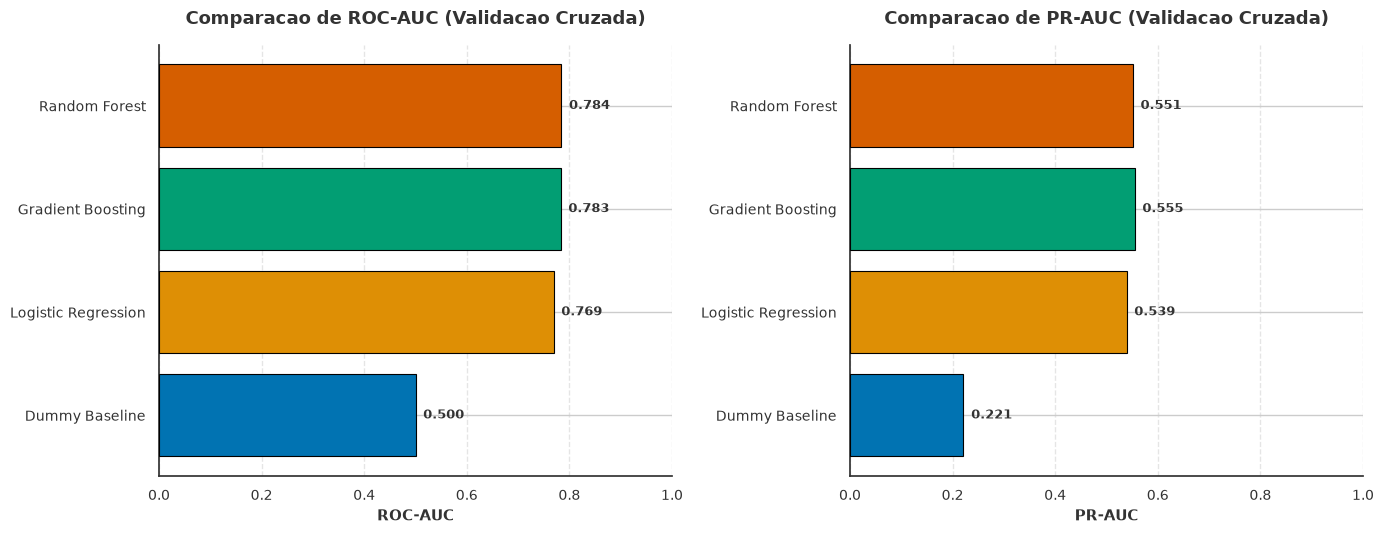

In [45]:
# Visualizacao comparativa dos modelos (ROC-AUC e PR-AUC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sorted_models = model_comparison.sort_values("roc_auc_mean", ascending=True)
colors = sns.color_palette("colorblind", n_colors=len(sorted_models))

# ROC-AUC
bars0 = axes[0].barh(sorted_models["model"], sorted_models["roc_auc_mean"], color=colors, edgecolor="black", linewidth=0.8, zorder=3)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("ROC-AUC", fontweight="bold")
axes[0].set_title("Comparacao de ROC-AUC (Validacao Cruzada)", fontweight="bold", pad=15)
axes[0].xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
for i, v in enumerate(sorted_models["roc_auc_mean"]):
    axes[0].text(v + 0.015, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")

# PR-AUC
bars1 = axes[1].barh(sorted_models["model"], sorted_models["pr_auc_mean"], color=colors, edgecolor="black", linewidth=0.8, zorder=3)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("PR-AUC", fontweight="bold")
axes[1].set_title("Comparacao de PR-AUC (Validacao Cruzada)", fontweight="bold", pad=15)
axes[1].xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
for i, v in enumerate(sorted_models["pr_auc_mean"]):
    axes[1].text(v + 0.015, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


## 7. Otimização de Hiperparâmetros

O **GradientBoostingClassifier** foi escolhido para otimização por apresentar desempenho competitivo na validação cruzada e boa adequação a dados tabulares. A escolha foi feita usando apenas os dados de treino, antes de qualquer avaliação no conjunto de teste.

> **Nota didática:** em um MVP, não é necessário explorar uma grade enorme de hiperparâmetros. O objetivo é obter uma configuração defensável com custo computacional modesto. A seguir, aplicamos uma busca reduzida (`n_iter=6`, 3 folds) sobre os parâmetros mais influentes de gradient boosting: número de árvores, taxa de aprendizado, profundidade e subsample.

### Hiperparâmetros Otimizados

| Hiperparâmetro | Valores Testados | Descrição |
|----------------|------------------|-----------|
| `n_estimators` | [80, 120] | Número de árvores no ensemble |
| `learning_rate` | [0.05, 0.10] | Taxa de contribuição de cada árvore |
| `max_depth` | [2, 3] | Profundidade máxima de cada árvore |
| `subsample` | [0.8, 1.0] | Fração de amostras usadas em cada árvore |

A estimativa de CV da configuração vencedora é usada para seleção. Como ela é o máximo entre configurações pesquisadas, pode ser otimista; o conjunto de teste permanece reservado para uma única avaliação final independente.


In [46]:
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Busca: 6 combinações × 3 folds = 18 ajustes.
param_distributions = {
    "model__n_estimators": [80, 120],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0]
}

cv_tuning = StratifiedKFold(
    n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE
)

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=_parse_env("GB_RANDOM_SEARCH_ITER", "6", int),
    scoring=scoring,
    refit="roc_auc",
    cv=cv_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start_time = time.perf_counter()
gb_random_search.fit(X_train, y_train)
optimization_time = time.perf_counter() - start_time

print(f"Tempo total da otimização: {optimization_time:.2f} segundos")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Tempo total da otimização: 25.49 segundos


In [47]:
# Melhores hiperparâmetros encontrados
print("Melhores hiperparâmetros:")
print(gb_random_search.best_params_)
print(f"\nMelhor ROC-AUC (CV): {gb_random_search.best_score_:.4f}")

# Top 10 configurações
search_results = pd.DataFrame(gb_random_search.cv_results_)

cols_to_show = [
    col for col in search_results.columns
    if col.startswith("rank_test")
    or col.startswith("mean_test")
    or col.startswith("std_test")
    or col.startswith("mean_train")
    or col == "params"
]

display(search_results[cols_to_show].sort_values("rank_test_roc_auc").head(10).round(4))


Melhores hiperparâmetros:
{'model__subsample': 0.8, 'model__n_estimators': 120, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Melhor ROC-AUC (CV): 0.7838


,params,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_train_accuracy,mean_test_precision,std_test_precision,rank_test_precision,mean_train_precision,mean_test_recall,std_test_recall,rank_test_recall,mean_train_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_train_f1,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc,mean_train_roc_auc,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc,mean_train_pr_auc
3,"{'model__subsample': 0.8, 'model__n_estimators...",0.8216,0.0021,2,0.8315,0.6765,0.0105,6,0.7162,0.3709,0.0033,1,0.3949,0.4791,0.0047,1,0.5090,0.7838,0.0045,1,0.8216,0.5538,0.0072,2,0.6258
4,"{'model__subsample': 1.0, 'model__n_estimators...",0.8217,0.0029,1,0.8288,0.6836,0.0125,4,0.7124,0.3613,0.0064,2,0.3788,0.4727,0.0084,2,0.4946,0.7830,0.0039,2,0.8109,0.5550,0.0050,1,0.6078
5,"{'model__subsample': 1.0, 'model__n_estimators...",0.8201,0.0022,4,0.8251,0.6793,0.0107,5,0.7004,0.3537,0.0029,3,0.3661,0.4652,0.0051,3,0.4808,0.7824,0.0037,3,0.8013,0.5504,0.0068,4,0.5843
2,"{'model__subsample': 1.0, 'model__n_estimators...",0.8204,0.0022,3,0.8252,0.6878,0.0091,3,0.7117,0.3441,0.0064,4,0.3531,0.4587,0.0076,4,0.4720,0.7801,0.0029,4,0.7964,0.5529,0.0054,3,0.5885
0,"{'model__subsample': 0.8, 'model__n_estimators...",0.8193,0.0022,5,0.8212,0.6904,0.0117,1,0.6996,0.3317,0.0045,5,0.3358,0.4481,0.0060,5,0.4538,0.7762,0.0024,5,0.7847,0.5464,0.0049,5,0.5608
1,"{'model__subsample': 1.0, 'model__n_estimators...",0.8184,0.0022,6,0.8210,0.6896,0.0112,2,0.7020,0.3255,0.0043,6,0.3318,0.4422,0.0060,6,0.4506,0.7760,0.0020,6,0.7847,0.5461,0.0057,6,0.5614


In [48]:
# Comparação entre Gradient Boosting original e otimizado
best_index = gb_random_search.best_index_

tuned_result = {
    "model": "Gradient Boosting Tuned",
    "training_time_seconds": optimization_time
}

for metric in scoring.keys():
    tuned_result[f"{metric}_mean"] = gb_random_search.cv_results_[f"mean_test_{metric}"][best_index]
    tuned_result[f"{metric}_std"] = gb_random_search.cv_results_[f"std_test_{metric}"][best_index]
    tuned_result[f"{metric}_train_mean"] = gb_random_search.cv_results_[f"mean_train_{metric}"][best_index]
    tuned_result[f"{metric}_gap"] = (
        tuned_result[f"{metric}_train_mean"] - tuned_result[f"{metric}_mean"]
    )

tuned_result_df = pd.DataFrame([tuned_result])
model_comparison_all = pd.concat(
    [cv_results_df, tuned_result_df],
    ignore_index=True,
    sort=False
)

comparison_columns = [
    "model",
    "roc_auc_mean",
    "pr_auc_mean",
    "recall_mean",
    "precision_mean",
    "f1_mean",
    "accuracy_mean",
    "roc_auc_train_mean",
    "roc_auc_gap"
]

display(
    model_comparison_all[comparison_columns]
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

# Seleção formal antes de qualquer acesso ao teste
MAX_ROC_AUC_GAP = _parse_env("MAX_ROC_AUC_GAP", "0.05", float)
selection_table = model_comparison_all.copy()
selection_table["eligible"] = selection_table["roc_auc_gap"] <= MAX_ROC_AUC_GAP

eligible_models = selection_table[selection_table["eligible"]].copy()
if eligible_models.empty:
    selection_pool = selection_table.sort_values(
        ["roc_auc_gap", "roc_auc_mean"], ascending=[True, False]
    )
    selection_reason = "fallback: nenhum candidato respeitou o gap máximo"
else:
    selection_pool = eligible_models.sort_values(
        ["roc_auc_mean", "roc_auc_gap"], ascending=[False, True]
    )
    selection_reason = f"maior ROC-AUC entre candidatos com gap <= {MAX_ROC_AUC_GAP:.2f}"

selected_model_name = selection_pool.iloc[0]["model"]
model_estimators = {**pipelines, "Gradient Boosting Tuned": gb_random_search.best_estimator_}
best_tuned_model = gb_random_search.best_estimator_
selected_model = model_estimators[selected_model_name]

rf_row = selection_table.loc[selection_table["model"] == "Random Forest"].iloc[0]
selected_cv_row = selection_table.loc[selection_table["model"] == selected_model_name].iloc[0]

display(selection_table[
    ["model", "roc_auc_mean", "roc_auc_gap", "eligible"]
].sort_values(["eligible", "roc_auc_mean"], ascending=[False, False]).round(4))

selection_text = f"""
### Decisão quantitativa

O **{selected_model_name}** foi selecionado por **{selection_reason}**. Seu ROC-AUC médio foi
**{selected_cv_row['roc_auc_mean']:.4f}**, com gap **{selected_cv_row['roc_auc_gap']:.4f}**.
A Random Forest obteve ROC-AUC **{rf_row['roc_auc_mean']:.4f}**, mas gap **{rf_row['roc_auc_gap']:.4f}**.
Assim, um ganho de apenas **{rf_row['roc_auc_mean'] - selected_cv_row['roc_auc_mean']:.4f}** em ROC-AUC
não compensou o excesso de sobreajuste, e a Random Forest ficou inelegível pela regra definida previamente.
"""
display(Markdown(selection_text))
print(f"Modelo final selecionado por CV no treino: {selected_model_name}")


,model,roc_auc_mean,pr_auc_mean,recall_mean,precision_mean,f1_mean,accuracy_mean,roc_auc_train_mean,roc_auc_gap
0,Random Forest,0.7842,0.5514,0.6141,0.4884,0.5441,0.7723,0.8789,0.0947
1,Gradient Boosting Tuned,0.7838,0.5538,0.3709,0.6765,0.4791,0.8216,0.8216,0.0378
2,Gradient Boosting,0.7830,0.5550,0.3613,0.6836,0.4727,0.8217,0.8109,0.0279
3,Logistic Regression,0.7692,0.5392,0.5801,0.4917,0.5322,0.7742,0.7764,0.0072
4,Dummy Baseline,0.5000,0.2212,0.0000,0.0000,0.0000,0.7788,0.5000,0.0000


,model,roc_auc_mean,roc_auc_gap,eligible
4,Gradient Boosting Tuned,0.7838,0.0378,True
3,Gradient Boosting,0.7830,0.0279,True
1,Logistic Regression,0.7692,0.0072,True
0,Dummy Baseline,0.5000,0.0000,True
2,Random Forest,0.7842,0.0947,False



### Decisão quantitativa

O **Gradient Boosting Tuned** foi selecionado por **maior ROC-AUC entre candidatos com gap <= 0.05**. Seu ROC-AUC médio foi
**0.7838**, com gap **0.0378**.
A Random Forest obteve ROC-AUC **0.7842**, mas gap **0.0947**.
Assim, um ganho de apenas **0.0005** em ROC-AUC
não compensou o excesso de sobreajuste, e a Random Forest ficou inelegível pela regra definida previamente.


Modelo final selecionado por CV no treino: Gradient Boosting Tuned


## 8. Escolha do Limiar no Treino

O limiar padrão de 0,5 não representa necessariamente o custo do problema. Para evitar vazamento, o limiar é escolhido usando **previsões out-of-fold exclusivamente de `X_train`**. Cada observação recebe uma probabilidade produzida por um modelo que não foi treinado com ela.

Como exercício acadêmico, atribui-se custo ilustrativo **5** a cada falso negativo e **1** a cada falso positivo. Esses valores não são uma estimativa financeira real; servem para tornar explícita a consequência de priorizar a detecção de inadimplentes. O teste permanece intocado até a próxima seção.


,threshold,precision,recall,f1,false_negatives,false_positives,illustrative_cost
3,0.16,0.3774,0.7517,0.5025,1318,6583,13173
10,0.30,0.5518,0.5287,0.5400,2502,2280,14790
15,0.40,0.6257,0.4304,0.5100,3024,1367,16487
20,0.50,0.6764,0.3709,0.4791,3340,942,17642


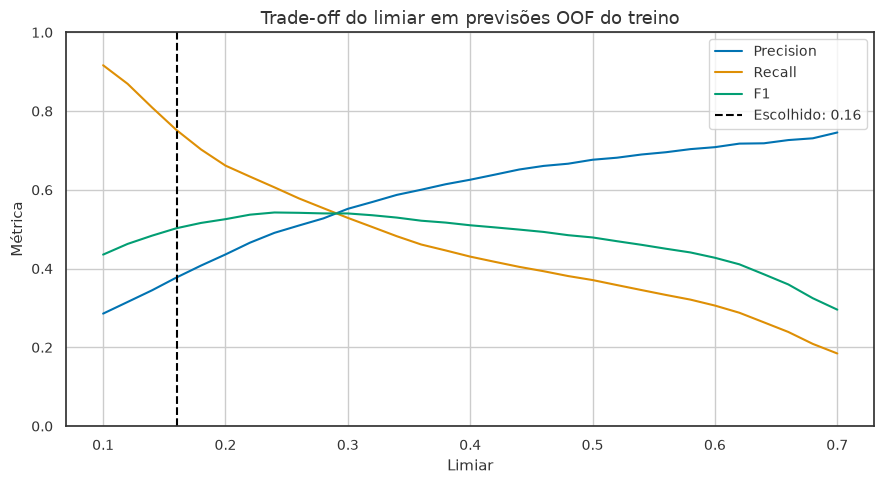

Limiar pré-selecionado no treino: 0.16
Custo ilustrativo: FN=5, FP=1


In [49]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

# OOF evita escolher o limiar a partir de previsões ajustadas ou do teste.
oof_scores = cross_val_predict(
    clone(selected_model), X_train, y_train,
    cv=cv_tuning, method="predict_proba", n_jobs=-1
)[:, 1]

FN_COST = _parse_env("FN_COST", "5", int)
FP_COST = _parse_env("FP_COST", "1", int)
THRESHOLD_MIN = _parse_env("THRESHOLD_MIN", "0.10", float)
THRESHOLD_MAX = _parse_env("THRESHOLD_MAX", "0.70", float)
THRESHOLD_STEP = _parse_env("THRESHOLD_STEP", "0.02", float)
threshold_grid = np.round(np.arange(THRESHOLD_MIN, THRESHOLD_MAX + THRESHOLD_STEP / 2, THRESHOLD_STEP), 2)
threshold_rows = []
for threshold in threshold_grid:
    pred = (oof_scores >= threshold).astype(int)
    fn = int(((y_train == 1) & (pred == 0)).sum())
    fp = int(((y_train == 0) & (pred == 1)).sum())
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_train, pred, zero_division=0),
        "recall": recall_score(y_train, pred, zero_division=0),
        "f1": f1_score(y_train, pred, zero_division=0),
        "false_negatives": fn,
        "false_positives": fp,
        "illustrative_cost": FN_COST * fn + FP_COST * fp,
    })

threshold_analysis = pd.DataFrame(threshold_rows)
selected_threshold = float(
    threshold_analysis.sort_values(["illustrative_cost", "threshold"]).iloc[0]["threshold"]
)

display(threshold_analysis.loc[
    threshold_analysis["threshold"].isin([0.30, 0.40, 0.50, selected_threshold])
].drop_duplicates().sort_values("threshold").round(4))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(threshold_analysis["threshold"], threshold_analysis["precision"], label="Precision")
ax1.plot(threshold_analysis["threshold"], threshold_analysis["recall"], label="Recall")
ax1.plot(threshold_analysis["threshold"], threshold_analysis["f1"], label="F1")
ax1.axvline(selected_threshold, color="black", linestyle="--", label=f"Escolhido: {selected_threshold:.2f}")
ax1.set(xlabel="Limiar", ylabel="Métrica", ylim=(0, 1), title="Trade-off do limiar em previsões OOF do treino")
ax1.legend(); plt.tight_layout(); plt.show()

print(f"Limiar pré-selecionado no treino: {selected_threshold:.2f}")
print(f"Custo ilustrativo: FN={FN_COST}, FP={FP_COST}")

## 9. Avaliação Final

Esta é a **primeira e única etapa** em que o conjunto de teste é utilizado. O modelo final já foi fixado como **Gradient Boosting Tuned** com base na validação cruzada e na otimização realizadas exclusivamente no treino.

### Por Que Apenas Dois Modelos São Avaliados no Teste?

A comparação entre Regressão Logística, Random Forest e Gradient Boosting foi concluída anteriormente por validação cruzada exclusivamente nos dados de treino. Depois dessa comparação e da otimização, o **Gradient Boosting Tuned** foi fixado como modelo final antes de qualquer acesso ao teste.

Por isso, somente dois modelos são avaliados no conjunto de teste: o `DummyClassifier`, que fornece a referência ingênua, e o modelo final pré-selecionado. Avaliar todos os candidatos no teste e escolher o melhor resultado produziria viés de seleção e faria o teste deixar de representar uma avaliação final independente. Assim, as métricas do teste servem apenas para estimar a generalização do modelo já escolhido, e não para trocar, ranquear ou selecionar modelos.


In [50]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)


def get_positive_class_scores(model, X):
    'Retorna o score da classe positiva usado nas métricas de ranking.'
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise TypeError(
        f"Model {type(model).__name__} exposes neither predict_proba nor "
        f"decision_function; cannot compute ranking scores."
    )


def evaluate_binary_classifier(model, X, y, model_name, split_name):
    'Calcula métricas de classificação binária para um conjunto informado.'
    y_pred = model.predict(X)
    y_score = get_positive_class_scores(model, X)

    results = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
    }

    results["roc_auc"] = roc_auc_score(y, y_score)
    results["pr_auc"] = average_precision_score(y, y_score)

    return results


# O teste é avaliado somente para o baseline e para o modelo previamente selecionado.
# O modelo otimizado já está ajustado (RandomizedSearchCV com refit='roc_auc'),
# então reaproveitamos best_estimator_ em vez de reajustar.
final_models = {
    "Dummy Baseline": pipelines["Dummy Baseline"],
    selected_model_name: selected_model,
}

fitted_models = {}
evaluation_results = []

for model_name, model in final_models.items():
    if model_name == selected_model_name and model_name == "Gradient Boosting Tuned":
        # A busca já reajustou o vencedor em todo o treino.
        fitted_models[model_name] = model
    else:
        model_to_fit = clone(model)
        model_to_fit.fit(X_train, y_train)
        fitted_models[model_name] = model_to_fit
        model = model_to_fit

    evaluation_results.append(
        evaluate_binary_classifier(model, X_train, y_train, model_name, "train")
    )
    evaluation_results.append(
        evaluate_binary_classifier(model, X_test, y_test, model_name, "test")
    )

evaluation_df = pd.DataFrame(evaluation_results)
test_results = (
    evaluation_df[evaluation_df["split"] == "test"]
    .reset_index(drop=True)
)

display(test_results.round(4))


# O teste apenas reporta o efeito do limiar que já foi fixado no treino.
y_score_selected_test = get_positive_class_scores(fitted_models[selected_model_name], X_test)
threshold_test_rows = []
for label, threshold in [("Padrão 0.50", 0.50), ("Pré-selecionado no treino", selected_threshold)]:
    pred = (y_score_selected_test >= threshold).astype(int)
    threshold_test_rows.append({
        "limiar": label,
        "valor": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "false_negatives": int(((y_test == 1) & (pred == 0)).sum()),
        "false_positives": int(((y_test == 0) & (pred == 1)).sum()),
    })
threshold_test_results = pd.DataFrame(threshold_test_rows)
display(threshold_test_results.round(4))


,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Baseline,test,0.7788,0.0000,0.0000,0.0000,0.5000,0.2212
1,Gradient Boosting Tuned,test,0.8180,0.6639,0.3587,0.4658,0.7824,0.5552


,limiar,valor,precision,recall,f1,false_negatives,false_positives
0,Padrão 0.50,0.50,0.6639,0.3587,0.4658,851,241
1,Pré-selecionado no treino,0.16,0.3721,0.7506,0.4975,331,1681


In [51]:
# Comparação treino versus teste para o modelo final e o baseline
train_results = evaluation_df[evaluation_df["split"] == "train"].copy()
test_results_aux = evaluation_df[evaluation_df["split"] == "test"].copy()

overfit_analysis = train_results.merge(
    test_results_aux,
    on="model",
    suffixes=("_train", "_test")
)

overfit_analysis["roc_auc_gap"] = (
    overfit_analysis["roc_auc_train"] - overfit_analysis["roc_auc_test"]
)
overfit_analysis["f1_gap"] = (
    overfit_analysis["f1_train"] - overfit_analysis["f1_test"]
)

columns_to_show = [
    "model",
    "roc_auc_train",
    "roc_auc_test",
    "roc_auc_gap",
    "f1_train",
    "f1_test",
    "f1_gap"
]
display(overfit_analysis[columns_to_show].round(4))

selected_gap_row = overfit_analysis.loc[
    overfit_analysis["model"] == selected_model_name
].iloc[0]
rf_cv_row = cv_results_df.loc[
    cv_results_df["model"] == "Random Forest"
].iloc[0]
lr_cv_row = cv_results_df.loc[
    cv_results_df["model"] == "Logistic Regression"
].iloc[0]

overfit_text = f"""
### Discussão quantitativa de overfitting e underfitting

- O modelo final apresentou ROC-AUC de **{selected_gap_row['roc_auc_train']:.4f} no treino** e **{selected_gap_row['roc_auc_test']:.4f} no teste**, com gap de **{selected_gap_row['roc_auc_gap']:.4f}**. O gap é moderado e indica algum sobreajuste, mas não uma degradação extrema.
- Na validação cruzada, a Random Forest apresentou gap médio de ROC-AUC treino-validação de **{rf_cv_row['roc_auc_gap']:.4f}**, sinal de sobreajuste substancial em relação aos demais candidatos.
- A Regressão Logística apresentou ROC-AUC médio de validação de **{lr_cv_row['roc_auc_mean']:.4f}**. Seu gap foi menor, mas a capacidade discriminatória ficou abaixo dos ensembles, compatível com limitação de ajuste do modelo linear para este conjunto de relações.
- O Dummy Baseline tem ROC-AUC de 0,5 e recall zero com a estratégia de classe majoritária; ele representa subajuste deliberado e serve apenas como piso de comparação.
"""

display(Markdown(overfit_text))


,model,roc_auc_train,roc_auc_test,roc_auc_gap,f1_train,f1_test,f1_gap
0,Dummy Baseline,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000
1,Gradient Boosting Tuned,0.8128,0.7824,0.0305,0.4998,0.4658,0.0341



### Discussão quantitativa de overfitting e underfitting

- O modelo final apresentou ROC-AUC de **0.8128 no treino** e **0.7824 no teste**, com gap de **0.0305**. O gap é moderado e indica algum sobreajuste, mas não uma degradação extrema.
- Na validação cruzada, a Random Forest apresentou gap médio de ROC-AUC treino-validação de **0.0947**, sinal de sobreajuste substancial em relação aos demais candidatos.
- A Regressão Logística apresentou ROC-AUC médio de validação de **0.7692**. Seu gap foi menor, mas a capacidade discriminatória ficou abaixo dos ensembles, compatível com limitação de ajuste do modelo linear para este conjunto de relações.
- O Dummy Baseline tem ROC-AUC de 0,5 e recall zero com a estratégia de classe majoritária; ele representa subajuste deliberado e serve apenas como piso de comparação.


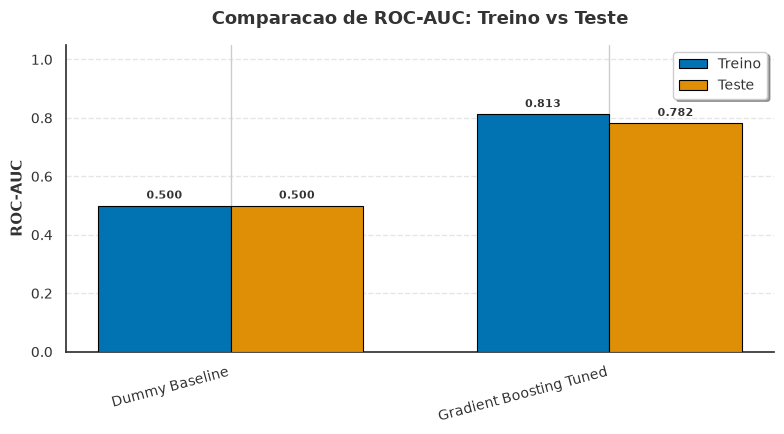

In [52]:
# Visualizacao do gap treino vs teste
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics_gap = overfit_analysis[["model", "roc_auc_train", "roc_auc_test"]].set_index("model")
x = np.arange(len(metrics_gap))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_gap["roc_auc_train"], width, label="Treino", color="#0173B2", edgecolor="black", linewidth=0.8, zorder=3)
bars2 = ax.bar(x + width/2, metrics_gap["roc_auc_test"], width, label="Teste", color="#DE8F05", edgecolor="black", linewidth=0.8, zorder=3)

ax.set_ylabel("ROC-AUC", fontweight="bold")
ax.set_title("Comparacao de ROC-AUC: Treino vs Teste", fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_gap.index, rotation=15, ha="right")
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
sns.despine(ax=ax)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.015, f"{height:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.015, f"{height:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()


In [53]:
# O modelo final foi selecionado antes da avaliação do teste
best_final_model_name = selected_model_name
best_final_model = fitted_models[best_final_model_name]

print(f"Modelo final pré-selecionado: {best_final_model_name}")

# Relatório de classificação no teste
y_pred_best = best_final_model.predict(X_test)
y_score_best = get_positive_class_scores(best_final_model, X_test)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - TESTE FINAL")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Não default", "Default"],
    zero_division=0
))


Modelo final pré-selecionado: Gradient Boosting Tuned

CLASSIFICATION REPORT - TESTE FINAL
              precision    recall  f1-score   support

 Não default       0.84      0.95      0.89      4673
     Default       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



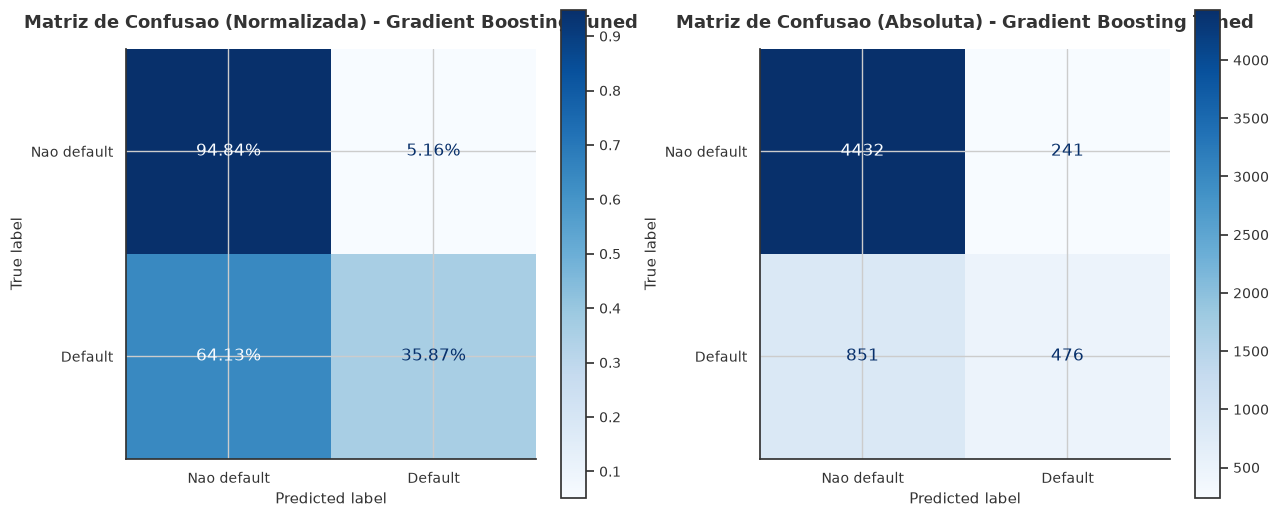

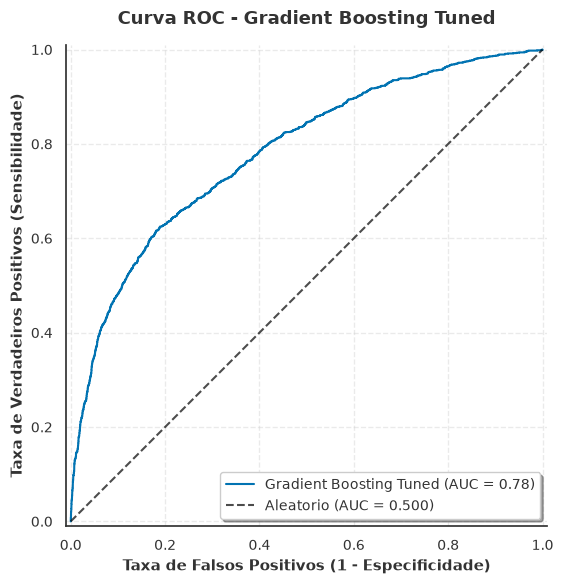

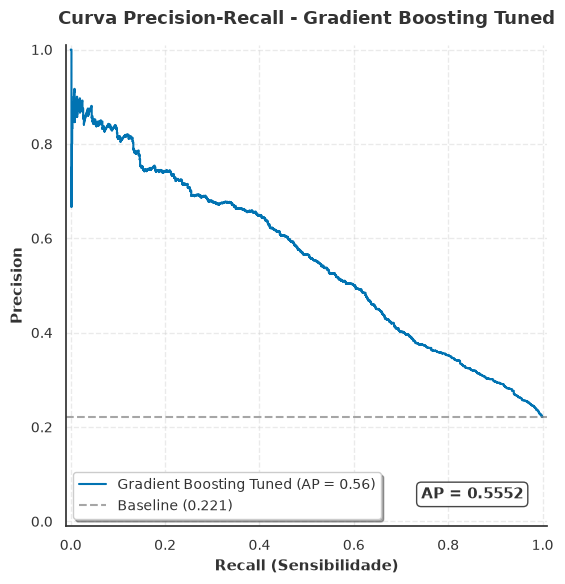

In [54]:
# Matriz de Confusao (normalizada e absoluta)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Normalizada
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Nao default", "Default"],
    ax=axes[0],
    cmap="Blues",
    colorbar=True,
    normalize="true",
    values_format=".2%"
)
axes[0].set_title(f"Matriz de Confusao (Normalizada) - {best_final_model_name}", fontweight="bold", pad=15)

# Absoluta
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Nao default", "Default"],
    ax=axes[1],
    cmap="Blues",
    colorbar=True,
    values_format="d"
)
axes[1].set_title(f"Matriz de Confusao (Absoluta) - {best_final_model_name}", fontweight="bold", pad=15)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Curva ROC
fig, ax = plt.subplots(figsize=(7, 6))
roc_display = RocCurveDisplay.from_estimator(
    best_final_model,
    X_test,
    y_test,
    ax=ax,
    name=best_final_model_name
)
ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC = 0.500)", linewidth=1.5, alpha=0.7)
ax.set_title(f"Curva ROC - {best_final_model_name}", fontweight="bold", pad=15)
ax.legend(loc="lower right", frameon=True, fancybox=True, shadow=True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontweight="bold")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Sensibilidade)", fontweight="bold")
sns.despine(ax=ax)

# Anotacao do AUC
auc_score = roc_auc_score(y_test, y_score_best)
ax.annotate(
    f"AUC = {auc_score:.4f}",
    xy=(0.95, 0.05),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#333333", alpha=0.9)
)
plt.tight_layout()
plt.show()

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 6))
pr_display = PrecisionRecallDisplay.from_estimator(
    best_final_model,
    X_test,
    y_test,
    ax=ax,
    name=best_final_model_name
)
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline ({baseline:.3f})", alpha=0.7)
ax.set_title(f"Curva Precision-Recall - {best_final_model_name}", fontweight="bold", pad=15)
ax.legend(loc="lower left", frameon=True, fancybox=True, shadow=True)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_xlabel("Recall (Sensibilidade)", fontweight="bold")
ax.set_ylabel("Precision", fontweight="bold")
sns.despine(ax=ax)

# Anotacao do AP
ap_score = average_precision_score(y_test, y_score_best)
ax.annotate(
    f"AP = {ap_score:.4f}",
    xy=(0.95, 0.05),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#333333", alpha=0.9)
)
plt.tight_layout()
plt.show()


## 10. Calibração e Fairness Exploratória

### Calibração

ROC-AUC avalia ordenação, mas não garante que uma previsão de 30% corresponda aproximadamente a 30% de eventos. Por isso, apresentamos o **Brier Score** e a curva de calibração. O diagnóstico no teste é somente avaliação final; não altera modelo nem limiar.

### Fairness exploratória por sexo

Comparamos métricas por grupo usando o limiar pré-selecionado no treino. Diferenças observadas não provam discriminação nem equidade: podem refletir composição da amostra, variáveis correlacionadas e incerteza estatística. Esta análise não é usada para retreinar, selecionar modelo ou alterar o limiar.


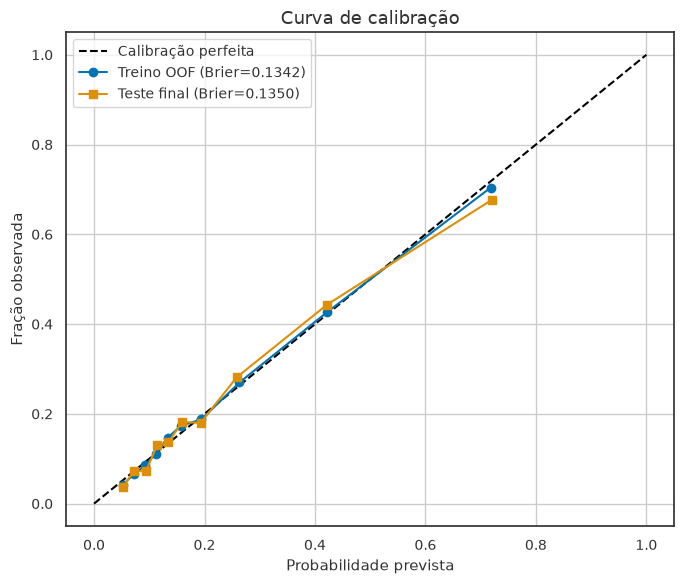

,grupo,n,prevalencia,selection_rate,recall_tpr,false_positive_rate,precision
0,female,3598,0.2129,0.4216,0.7428,0.3347,0.3751
1,male,2402,0.2336,0.4829,0.7611,0.3982,0.3681


Diferença absoluta de recall: 0.0183
Diferença absoluta de FPR: 0.0634
Análise exploratória: não constitui auditoria de fairness nem evidência causal.


In [55]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

oof_brier = brier_score_loss(y_train, oof_scores)
test_brier = brier_score_loss(y_test, y_score_selected_test)
prob_true_oof, prob_pred_oof = calibration_curve(y_train, oof_scores, n_bins=10, strategy="quantile")
prob_true_test, prob_pred_test = calibration_curve(y_test, y_score_selected_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibração perfeita")
ax.plot(prob_pred_oof, prob_true_oof, marker="o", label=f"Treino OOF (Brier={oof_brier:.4f})")
ax.plot(prob_pred_test, prob_true_test, marker="s", label=f"Teste final (Brier={test_brier:.4f})")
ax.set(xlabel="Probabilidade prevista", ylabel="Fração observada", title="Curva de calibração")
ax.legend(); plt.tight_layout(); plt.show()

fairness_frame = pd.DataFrame({
    "sexo": X_test["sexo"].astype(str),
    "y_true": y_test.to_numpy(),
    "y_pred": (y_score_selected_test >= selected_threshold).astype(int),
})

fairness_rows = []
for group, data in fairness_frame.groupby("sexo"):
    tn, fp, fn, tp = confusion_matrix(data["y_true"], data["y_pred"], labels=[0, 1]).ravel()
    fairness_rows.append({
        "grupo": group,
        "n": len(data),
        "prevalencia": data["y_true"].mean(),
        "selection_rate": data["y_pred"].mean(),
        "recall_tpr": tp / (tp + fn) if tp + fn else np.nan,
        "false_positive_rate": fp / (fp + tn) if fp + tn else np.nan,
        "precision": tp / (tp + fp) if tp + fp else np.nan,
    })

fairness_results = pd.DataFrame(fairness_rows)
display(fairness_results.round(4))

if len(fairness_results) == 2:
    print("Diferença absoluta de recall:", round(fairness_results["recall_tpr"].max() - fairness_results["recall_tpr"].min(), 4))
    print("Diferença absoluta de FPR:", round(fairness_results["false_positive_rate"].max() - fairness_results["false_positive_rate"].min(), 4))
print("Análise exploratória: não constitui auditoria de fairness nem evidência causal.")

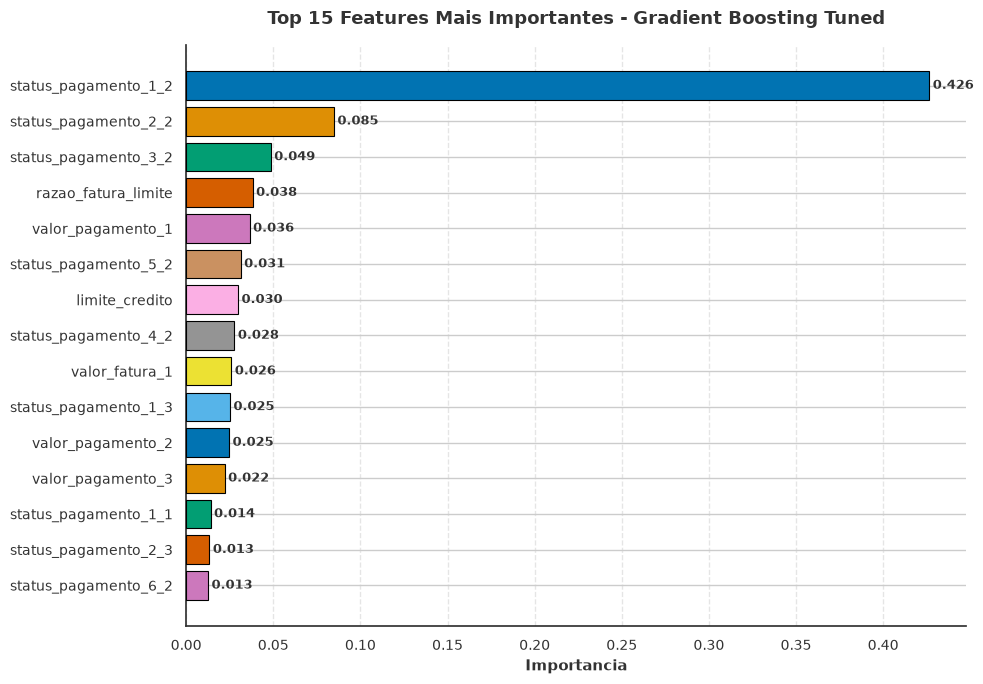

In [56]:
# Importancia das features (Gradient Boosting)
feature_importances = best_final_model.named_steps["model"].feature_importances_

# Recupera nomes das features apos pre-processamento
preprocessor_fitted = best_final_model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()

# Limpa prefixos do ColumnTransformer para legibilidade
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

importance_df = pd.DataFrame({
    "feature": clean_names,
    "importance": feature_importances
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("colorblind", n_colors=len(importance_df))
bars = ax.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
    color=colors[::-1],
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)
ax.set_xlabel("Importancia", fontweight="bold")
ax.set_title(f"Top 15 Features Mais Importantes - {best_final_model_name}", fontweight="bold", pad=15)
ax.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
sns.despine(ax=ax)

for i, v in enumerate(importance_df["importance"][::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


,model,roc_auc,pr_auc,recall,precision,f1,accuracy
0,Dummy Baseline,0.5000,0.2212,0.0000,0.0000,0.0000,0.7788
1,Gradient Boosting Tuned,0.7824,0.5552,0.3587,0.6639,0.4658,0.8180


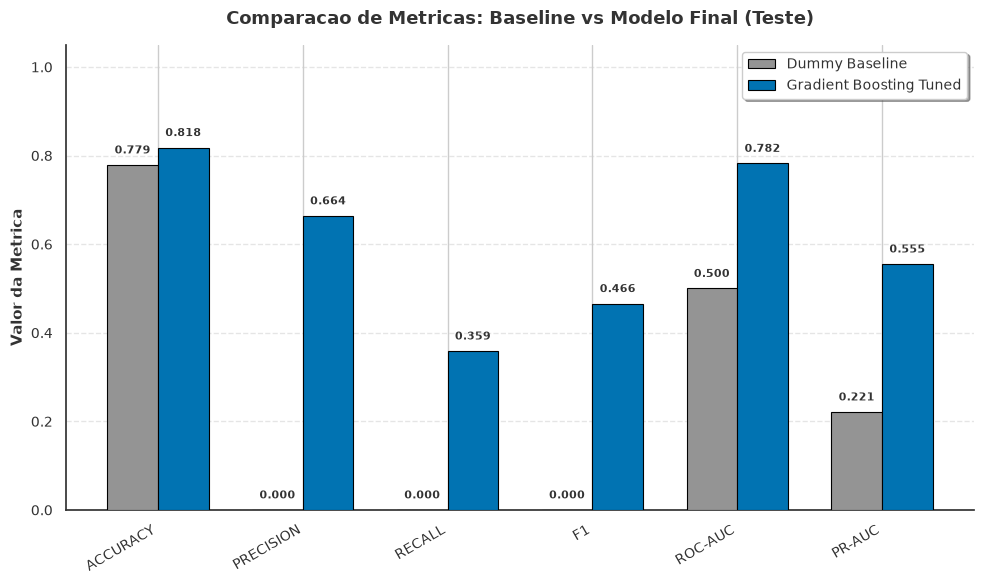

In [57]:
# Comparacao entre o baseline e o modelo final pre-selecionado
baseline_vs_best = test_results[
    test_results["model"].isin(["Dummy Baseline", best_final_model_name])
][
    [
        "model",
        "roc_auc",
        "pr_auc",
        "recall",
        "precision",
        "f1",
        "accuracy"
    ]
]

display(baseline_vs_best.round(4))

# Comparacao visual de metricas no conjunto de teste
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
plot_df = baseline_vs_best.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    plot_df.loc["Dummy Baseline"],
    width,
    label="Dummy Baseline",
    color="#949494",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)
bars2 = ax.bar(
    x + width/2,
    plot_df.loc[best_final_model_name],
    width,
    label=best_final_model_name,
    color="#0173B2",
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

ax.set_ylabel("Valor da Metrica", fontweight="bold")
ax.set_title("Comparacao de Metricas: Baseline vs Modelo Final (Teste)", fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "-").upper() for m in metrics_to_plot], rotation=30, ha="right")
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.set_ylim(0, 1.05)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
sns.despine(ax=ax)

for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f"{height:.3f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()


### Discussão dos Resultados

A leitura dos resultados deve considerar simultaneamente discriminação e comportamento no limiar padrão de 0,5:

1. **ROC-AUC e PR-AUC:** medem a qualidade do ranqueamento de risco sem depender apenas da classe prevista;
2. **Recall da classe positiva:** indica a fração de inadimplentes identificada. Recall baixo significa muitos falsos negativos, um risco relevante em crédito;
3. **Precision:** indica quanto das sinalizações de default está correto;
4. **Baseline:** o `DummyClassifier` demonstra por que accuracy isolada é insuficiente em uma base desbalanceada;
5. **Overfitting:** os gaps calculados entre treino, validação cruzada e teste devem ser analisados junto com o desempenho absoluto;
6. **Uso do teste:** o teste foi acessado somente após a seleção do modelo final pelo treino e não foi usado para escolher o vencedor;
7. **Aplicabilidade:** os resultados não validam uso no Brasil ou em produção. Uma aplicação real exigiria validação externa e temporal, calibração, definição de custos, análise de viés, explicabilidade, governança e monitoramento.


## 11. Conclusão do MVP

A conclusão abaixo é gerada com os valores efetivamente calculados na execução, sem números fixos ou placeholders.


In [58]:
best_row = test_results.loc[test_results["model"] == selected_model_name].iloc[0]
baseline_row = test_results.loc[test_results["model"] == "Dummy Baseline"].iloc[0]
selected_gap_row = overfit_analysis.loc[overfit_analysis["model"] == selected_model_name].iloc[0]
missed_default_rate = 1 - best_row["recall"]

conclusion_text = f"""
### Conclusão baseada nos resultados executados

O **{selected_model_name}** foi definido antes do acesso ao teste pela regra formal: maior ROC-AUC de validação entre candidatos com gap treino-CV menor ou igual a {MAX_ROC_AUC_GAP:.2f}. Sua estimativa de ROC-AUC na seleção foi **{selected_cv_row['roc_auc_mean']:.4f}**.

No teste final, o modelo obteve accuracy **{best_row['accuracy']:.4f}**, precision **{best_row['precision']:.4f}**, recall **{best_row['recall']:.4f}**, F1 **{best_row['f1']:.4f}**, ROC-AUC **{best_row['roc_auc']:.4f}** e PR-AUC **{best_row['pr_auc']:.4f}**. No limiar padrão, aproximadamente **{missed_default_rate:.2%}** dos defaults não foram identificados.

O limiar **{selected_threshold:.2f}** foi escolhido sem consultar o teste, usando previsões out-of-fold e custos ilustrativos FN={FN_COST} e FP={FP_COST}. O Brier Score foi **{oof_brier:.4f}** no treino OOF e **{test_brier:.4f}** no teste, complementando a discriminação com calibração. A análise por sexo foi exploratória e não orientou ajustes.

O gap de ROC-AUC entre treino e teste foi **{selected_gap_row['roc_auc_gap']:.4f}**. A Random Forest foi rejeitada porque seu ganho marginal de ROC-AUC não compensou o gap treino-CV acima da regra predefinida.

As conclusões são limitadas pelos dados históricos de Taiwan, ausência de validação brasileira, custos apenas ilustrativos e análise de fairness sem inferência causal. O trabalho demonstra um fluxo acadêmico reproduzível, mas não autoriza decisões reais de crédito.
"""
display(Markdown(conclusion_text))



### Conclusão baseada nos resultados executados

O **Gradient Boosting Tuned** foi definido antes do acesso ao teste pela regra formal: maior ROC-AUC de validação entre candidatos com gap treino-CV menor ou igual a 0.05. Sua estimativa de ROC-AUC na seleção foi **0.7838**.

No teste final, o modelo obteve accuracy **0.8180**, precision **0.6639**, recall **0.3587**, F1 **0.4658**, ROC-AUC **0.7824** e PR-AUC **0.5552**. No limiar padrão, aproximadamente **64.13%** dos defaults não foram identificados.

O limiar **0.16** foi escolhido sem consultar o teste, usando previsões out-of-fold e custos ilustrativos FN=5 e FP=1. O Brier Score foi **0.1342** no treino OOF e **0.1350** no teste, complementando a discriminação com calibração. A análise por sexo foi exploratória e não orientou ajustes.

O gap de ROC-AUC entre treino e teste foi **0.0305**. A Random Forest foi rejeitada porque seu ganho marginal de ROC-AUC não compensou o gap treino-CV acima da regra predefinida.

As conclusões são limitadas pelos dados históricos de Taiwan, ausência de validação brasileira, custos apenas ilustrativos e análise de fairness sem inferência causal. O trabalho demonstra um fluxo acadêmico reproduzível, mas não autoriza decisões reais de crédito.


## 12. Boas Práticas Esperadas

| Boa Prática | Evidência no notebook | Status |
|-------------|-----------------------|--------|
| **Seeds fixadas** | `RANDOM_STATE = 42` aplicado em numpy, random e modelos | Atendido |
| **Versões registradas** | Python, pandas, numpy e scikit-learn impressos | Atendido |
| **Pipeline completo** | Imputação, encoding/scaling e modelo no mesmo `Pipeline` | Atendido |
| **Variáveis categóricas** | `OneHotEncoder(handle_unknown="ignore")` | Atendido |
| **Variáveis numéricas** | `StandardScaler` após imputação mediana | Atendido |
| **Split estratificado** | `train_test_split(..., stratify=y)` | Atendido |
| **CV somente no treino** | `cross_validate` e `RandomizedSearchCV` recebem apenas treino; 3 folds equilibram rigor e custo no MVP | Atendido |
| **Seleção sem teste** | Modelo final fixado pela validação cruzada antes da avaliação final | Atendido |
| **Teste final reservado** | Somente baseline e modelo pré-selecionado são avaliados no teste | Atendido |
| **Métricas adequadas** | Accuracy, precision, recall, F1, ROC-AUC e PR-AUC | Atendido |
| **Diagnóstico de ajuste** | Comparações treino-validação e treino-teste com gaps calculados | Atendido |
| **Limitações explícitas** | Taiwan, dados históricos, ausência de validação brasileira e escopo acadêmico | Atendido |


In [59]:
notebook_total_seconds = time.perf_counter() - NOTEBOOK_START
print(f"Tempo total do notebook: {notebook_total_seconds:.2f} segundos ({notebook_total_seconds/60:.2f} minutos)")

Tempo total do notebook: 60.08 segundos (1.00 minutos)


In [60]:
# Checagens finais de objetos e consistência
required_objects = [
    "df", "X", "y", "X_train", "X_test", "y_train", "y_test",
    "preprocessor", "pipelines", "cv_results_df", "model_comparison_all",
    "selected_model_name", "selected_threshold", "test_results",
    "best_final_model", "fairness_results"
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Objetos ausentes: {missing_objects}"
assert df.shape == (30000, 24)
assert set(y.unique()) == {0, 1} and y.isna().sum() == 0
assert set(X_train.index).isdisjoint(set(X_test.index))
assert np.isclose(y_train.mean(), y_test.mean(), atol=0.001)
assert cv_screening.n_splits == CV_SPLITS and cv_tuning.n_splits == CV_SPLITS
assert gb_random_search.n_iter == int(os.getenv("GB_RANDOM_SEARCH_ITER", "6"))
assert selected_model_name in model_estimators
assert selected_cv_row["roc_auc_gap"] <= MAX_ROC_AUC_GAP
assert set(final_models) == {"Dummy Baseline", selected_model_name}
assert set(test_results["model"]) == {"Dummy Baseline", selected_model_name}
assert len(oof_scores) == len(y_train) and 0 < selected_threshold < 1
assert np.isfinite([oof_brier, test_brier]).all()
assert notebook_total_seconds > 0
assert {"recall_tpr", "false_positive_rate"}.issubset(fairness_results.columns)
metric_values = test_results[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_numpy(float)
assert np.isfinite(metric_values).all() and ((metric_values >= 0) & (metric_values <= 1)).all()
print("Todas as checagens finais foram concluídas com sucesso.")


Todas as checagens finais foram concluídas com sucesso.


## 13. Checklist Final


| Requisito | Atendido |
|-----------|----------|
| Código em Python | Sim |
| Markdown em português-BR | Sim |
| Dataset carregado pela URL raw do arquivo XLS no GitHub do MVP | Sim |
| Classificação supervisionada binária | Sim |
| Target `inadimplente_proximo_mes` | Sim |
| EDA e preparação dos dados | Sim |
| `Pipeline` e `ColumnTransformer` | Sim |
| Imputação dentro do pipeline | Sim |
| `OneHotEncoder` para categóricas | Sim |
| `StandardScaler` para numéricas | Sim |
| Split estratificado | Sim |
| Dummy, Regressão Logística, Random Forest e Gradient Boosting | Sim |
| Gradient Boosting otimizado | Sim |
| Validação cruzada e tuning somente no treino | Sim |
| Teste reservado para avaliação final | Sim |
| Accuracy, precision, recall, F1, ROC-AUC e PR-AUC | Sim |
| Tabela comparativa de modelos | Sim |
| Comparação treino versus teste | Sim |
| Matriz de confusão, curva ROC e curva Precision-Recall | Sim |
| Discussão quantitativa de overfitting/underfitting | Sim |
| Conclusão com valores computados | Sim |
| Limitações acadêmicas e geográficas explícitas | Sim |
| Asserções finais de consistência | Sim |
| Sem bibliotecas ou modelos proibidos | Sim |

### Checklist Sugerido da Disciplina

| Critério Acadêmico | Evidência no Notebook | Status |
|--------------------|------------------------|--------|
| Definição clara do problema de negócio | Objetivo, variável-alvo, tipo de tarefa e hipóteses apresentados | Atendido |
| Identificação e apresentação da base de dados | Nome, fonte UCI, ID 350, DOI, dimensões e variáveis descritos | Atendido |
| Análise exploratória dos dados | Tipos, estatísticas, ausências, distribuição do target, categorias e correlações | Atendido |
| Preparação dos dados | Limpeza de categorias, features derivadas, imputação, encoding e padronização | Atendido |
| Separação entre treino e teste | Divisão 80/20 estratificada e conjunto de teste reservado | Atendido |
| Construção de modelos de classificação | Dummy, Regressão Logística, Random Forest e Gradient Boosting | Atendido |
| Validação e comparação de modelos | Validação cruzada estratificada aplicada somente no treino | Atendido |
| Otimização de hiperparâmetros | `RandomizedSearchCV` aplicado ao Gradient Boosting somente no treino | Atendido |
| Avaliação final | Modelo pré-selecionado comparado ao baseline no conjunto de teste | Atendido |
| Métricas adequadas | Accuracy, precision, recall, F1-score, ROC-AUC e PR-AUC | Atendido |
| Visualizações de avaliação | Matriz de confusão, curva ROC e curva Precision-Recall | Atendido |
| Análise de overfitting e underfitting | Gaps entre treino, validação e teste calculados e discutidos | Atendido |
| Conclusão vinculada aos resultados | Valores calculados são inseridos dinamicamente na conclusão | Atendido |
| Limitações e aplicabilidade | Taiwan, amostra histórica, ausência de validação brasileira e escopo acadêmico | Atendido |
| Reprodutibilidade e organização | Seeds, versões, pipelines, células ordenadas e asserções finais | Atendido |


#XAKCN | Pontifícia Universidade Católica do Rio de Janeiro


